## **Hotel-booking Cancellation Prediction**

## 🎯 Problem Statement

To predict whether a hotel booking will be **canceled or not** using booking and customer-related information, helping hotels improve **revenue and resource planning**.


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn
from scipy import stats

In [ ]:
df=pd.read_csv("/content/hotel_bookings.csv")
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 32 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  object 
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  object 
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  int64  
 8   stays_in_week_nights            119390 non-null  int64  
 9   adults                          119390 non-null  int64  
 10  children                        119386 non-null  float64
 11  babies                          119390 non-null  int64  
 12  meal            

In [ ]:
df.head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03


In [ ]:
df.isnull().sum()

,0
hotel,0
is_canceled,0
lead_time,0
arrival_date_year,0
arrival_date_month,0
arrival_date_week_number,0
arrival_date_day_of_month,0
stays_in_weekend_nights,0
stays_in_week_nights,0
adults,0


In [ ]:
# Keep only the required columns for EDA and modeling
drop_columns = [
 'reservation_status',
    'reservation_status_date',
    'company',
    'arrival_date_year',
'arrival_date_week_number',
'arrival_date_day_of_month',
'reservation_status',
'reservation_status_date'
]
df = df.drop(columns=drop_columns)


In [ ]:
df.duplicated().sum()

np.int64(32468)

In [ ]:
df=df.drop_duplicates()

In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df['agent']=df["agent"].fillna(df["agent"].median())
df['children']=df["children"].fillna(df["children"].median())
df['country']=df["country"].fillna(df["country"].mode()[0])

In [ ]:
df.isnull().sum()

,0
hotel,0
is_canceled,0
lead_time,0
arrival_date_month,0
stays_in_weekend_nights,0
stays_in_week_nights,0
adults,0
children,0
babies,0
meal,0


In [ ]:
numerical_cols = df.select_dtypes(
    include=['int64', 'float64']
).columns
categorical_cols = df.select_dtypes(
    include=['object']
).columns
print(numerical_cols)
print(categorical_cols)
print("Numerical columns:", len(numerical_cols))
print("Categorical columns:", len(categorical_cols))


Index(['is_canceled', 'lead_time', 'stays_in_weekend_nights',
       'stays_in_week_nights', 'adults', 'children', 'babies',
       'is_repeated_guest', 'previous_cancellations',
       'previous_bookings_not_canceled', 'booking_changes', 'agent',
       'days_in_waiting_list', 'adr', 'required_car_parking_spaces',
       'total_of_special_requests'],
      dtype='object')
Index(['hotel', 'arrival_date_month', 'meal', 'country', 'market_segment',
       'distribution_channel', 'reserved_room_type', 'assigned_room_type',
       'deposit_type', 'customer_type'],
      dtype='object')
Numerical columns: 16
Categorical columns: 10


In [ ]:
df['is_canceled'].value_counts()

,count
is_canceled,
0,63177
1,23745


**Insight:** Most bookings are not canceled, while a smaller portion is canceled. This shows that cancellation is an important but less frequent outcome in the dataset.


In [ ]:
df['is_canceled'].value_counts(normalize=True) * 100

,proportion
is_canceled,
0,72.682405
1,27.317595


**Insight:** About **72.7%** of bookings are not canceled and **27.3%** are canceled. The target is therefore somewhat imbalanced, which should be considered during model evaluation.


In [ ]:
#Stay duration
df['total_nights'] = (
    df['stays_in_weekend_nights'] +
    df['stays_in_week_nights']
)

**Insight:** `total_nights` gives the complete length of stay by combining weekend and weekday nights. It is easier to use this single feature when studying stay duration.


In [ ]:
#Total guests
df['total_guests'] = (
    df['adults'] +
    df['children'] +
    df['babies']
)

**Insight:** `total_guests` combines adults, children, and babies. Most bookings are for a small number of guests, so this feature helps represent the booking size.


In [ ]:
#Total Previous Bookings
df['total_previous_bookings'] = (
    df['previous_cancellations'] +
    df['previous_bookings_not_canceled']
)

**Insight:** `total_previous_bookings` combines previous cancellations and previous successful bookings. It gives a simple view of the customer’s past booking history.


In [ ]:
#Total Special Requests
df['total_requests'] = (
    df['total_of_special_requests'] +
    df['required_car_parking_spaces']
)

**Insight:** `total_requests` combines special requests and parking spaces. A higher value may indicate customers who have more specific requirements for their stay.


In [ ]:
df[['total_nights', 'total_guests']].head()

,total_nights,total_guests
0,0,2.0
1,0,2.0
2,1,1.0
3,1,1.0
4,2,2.0


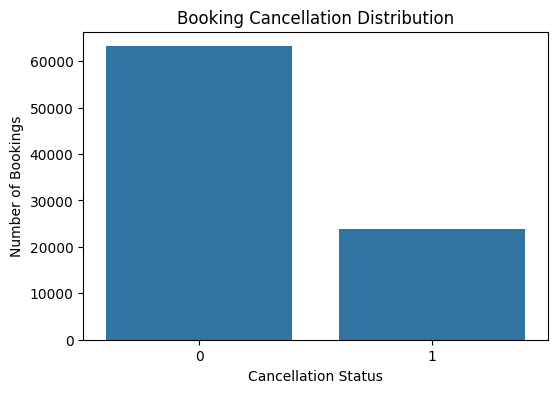

In [ ]:
plt.figure(figsize=(6,4))

sns.countplot(
    data=df,
    x='is_canceled'
)

plt.title("Booking Cancellation Distribution")
plt.xlabel("Cancellation Status")
plt.ylabel("Number of Bookings")
plt.show()

**Insight:** Non-canceled bookings are much higher than canceled bookings. This confirms that cancellation is the minority class in the target variable.


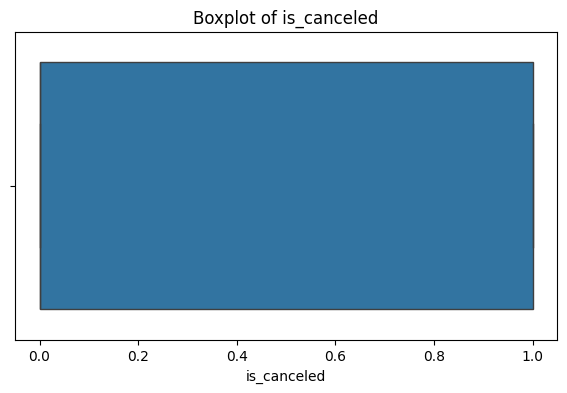

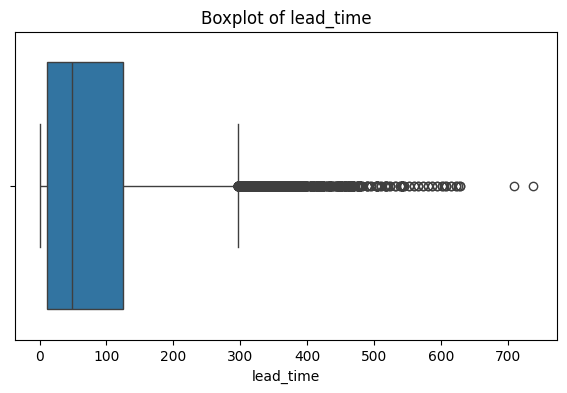

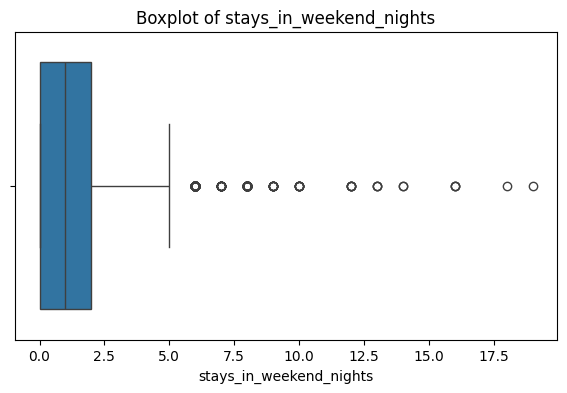

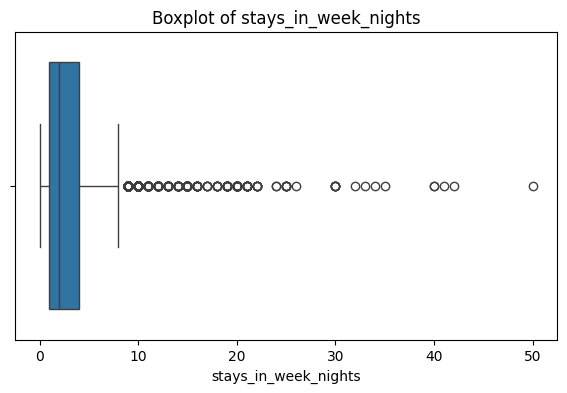

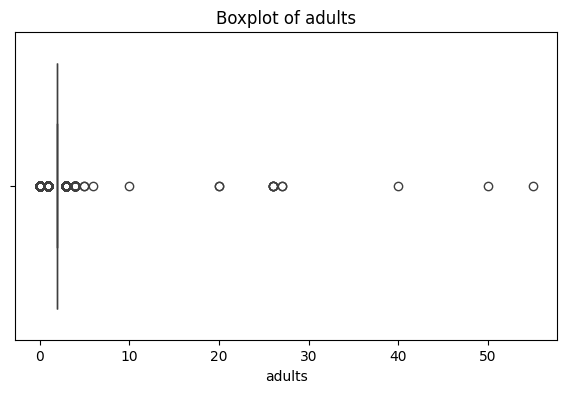

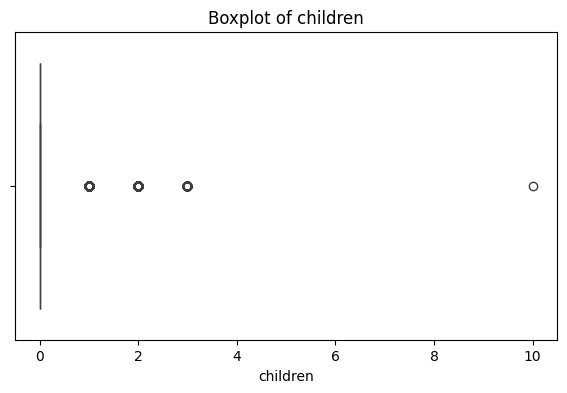

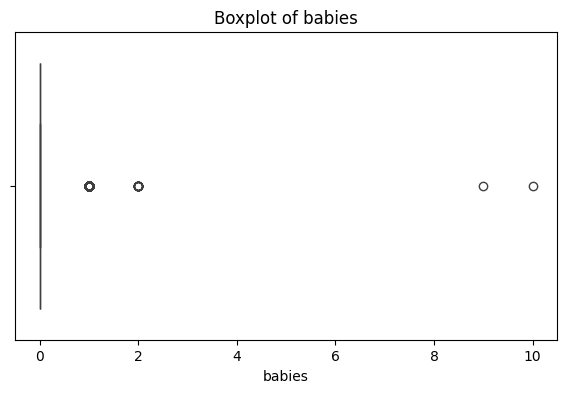

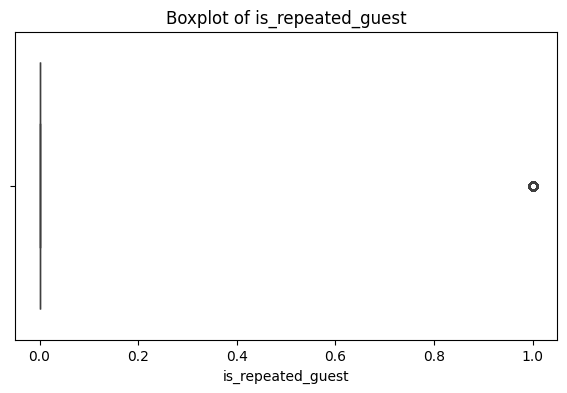

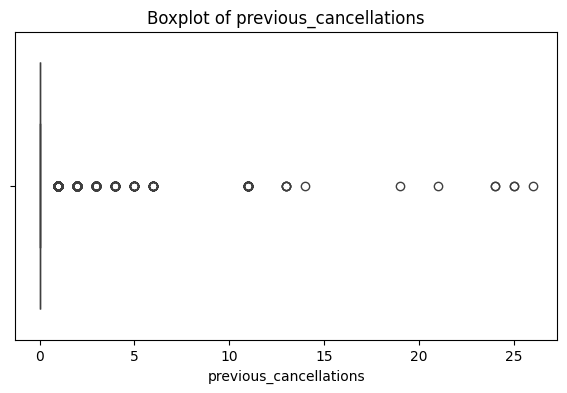

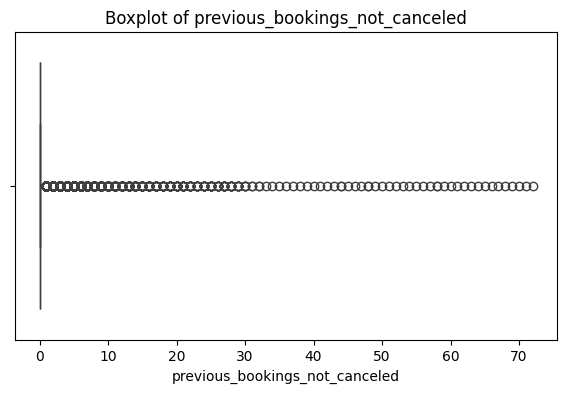

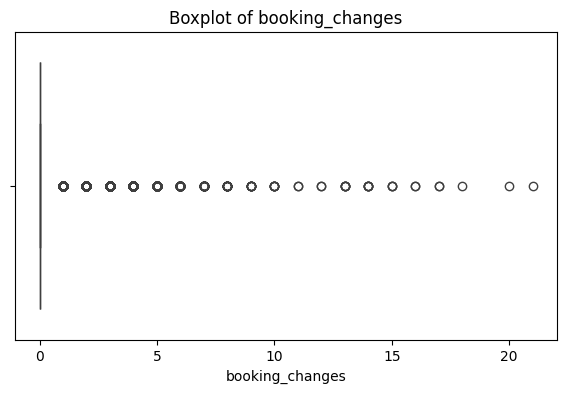

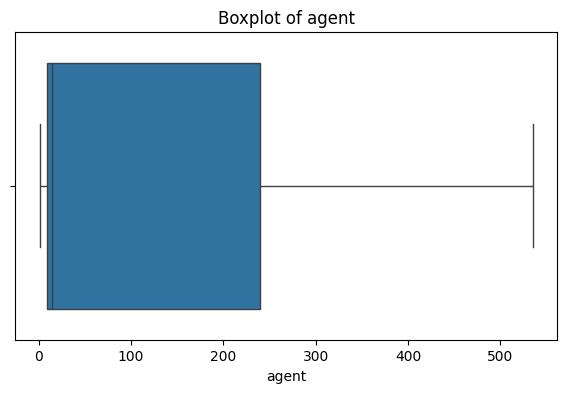

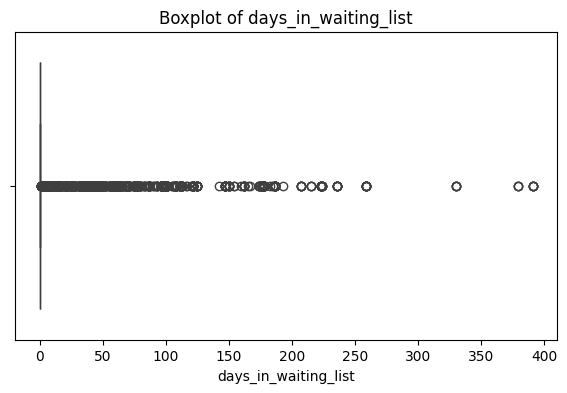

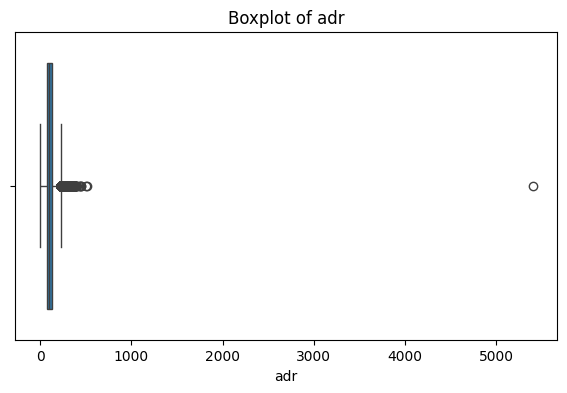

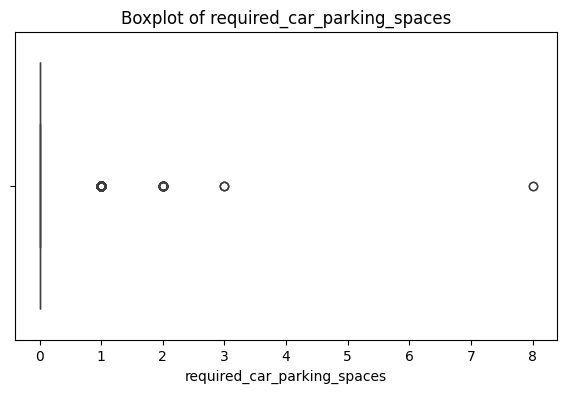

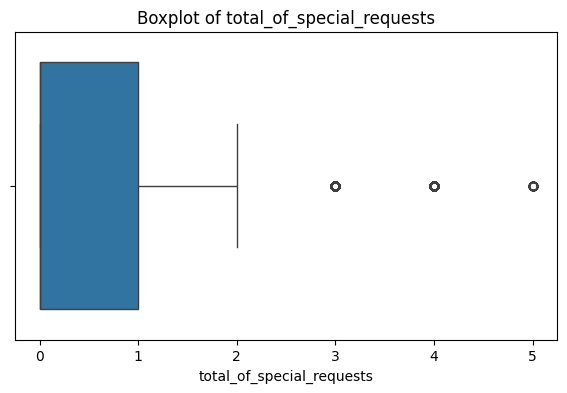

In [ ]:
for col in numerical_cols:

    plt.figure(figsize=(7,4))

    sns.boxplot(x=df[col])

    plt.title(f"Boxplot of {col}")

    plt.show()

**Insight:** Several numerical columns contain outliers. These unusual values should be checked before modeling, although genuine extreme bookings do not always need to be removed.


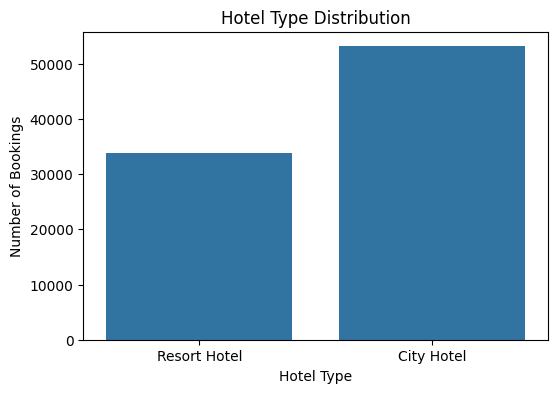

In [ ]:
#Hotel Type
plt.figure(figsize=(6,4))

sns.countplot(
    data=df,
    x='hotel'
)

plt.title("Hotel Type Distribution")
plt.xlabel("Hotel Type")
plt.ylabel("Number of Bookings")
plt.show()

**Insight:** City Hotel has more bookings than Resort Hotel. This means City Hotel contributes a larger share of the overall booking data.


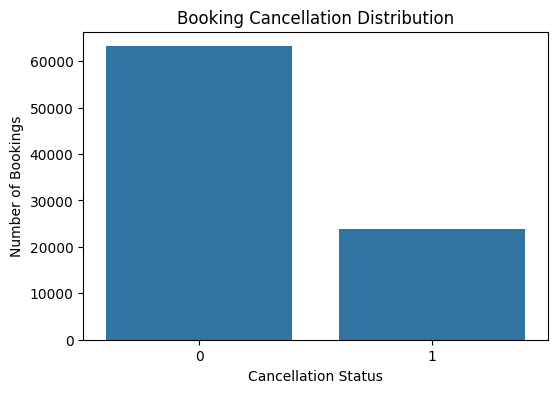

In [ ]:
#Booking Cancellation
plt.figure(figsize=(6,4))

sns.countplot(
    data=df,
    x='is_canceled'
)

plt.title("Booking Cancellation Distribution")
plt.xlabel("Cancellation Status")
plt.ylabel("Number of Bookings")
plt.show()

**Insight:** Most bookings are not canceled, while canceled bookings form a smaller share. This pattern is consistent with the target distribution.


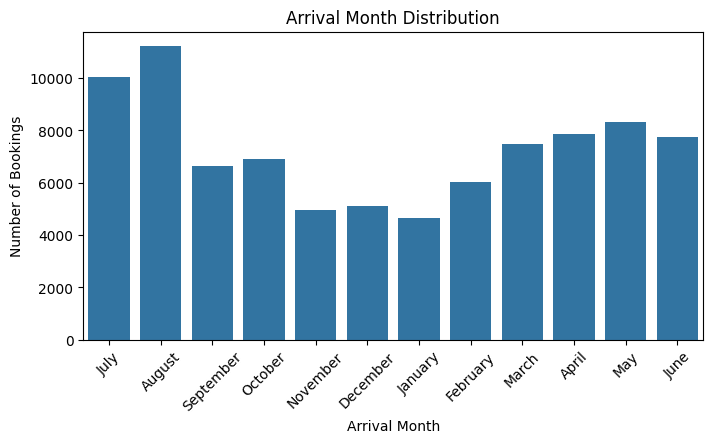

In [ ]:
#Arrival Month
plt.figure(figsize=(8,4))

sns.countplot(
    data=df,
    x='arrival_date_month'
)

plt.title("Arrival Month Distribution")
plt.xlabel("Arrival Month")
plt.ylabel("Number of Bookings")
plt.xticks(rotation=45)
plt.show()

**Insight:** Booking volume changes across months, showing seasonal demand. Some months have noticeably more bookings than others, so arrival month may be useful for prediction.


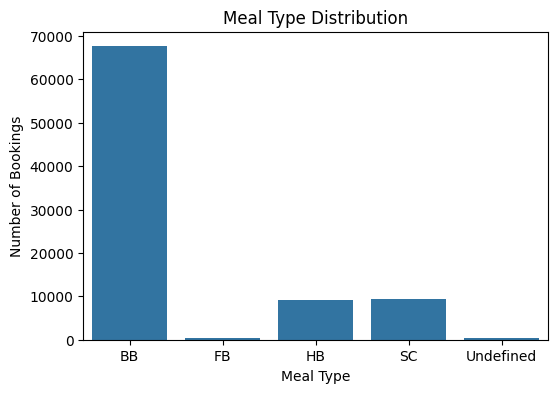

In [ ]:
#Meal Type
plt.figure(figsize=(6,4))

sns.countplot(
    data=df,
    x='meal'
)

plt.title("Meal Type Distribution")
plt.xlabel("Meal Type")
plt.ylabel("Number of Bookings")
plt.show()

**Insight:** BB is the most common meal type by a large margin. This means most customers choose a booking that includes breakfast.


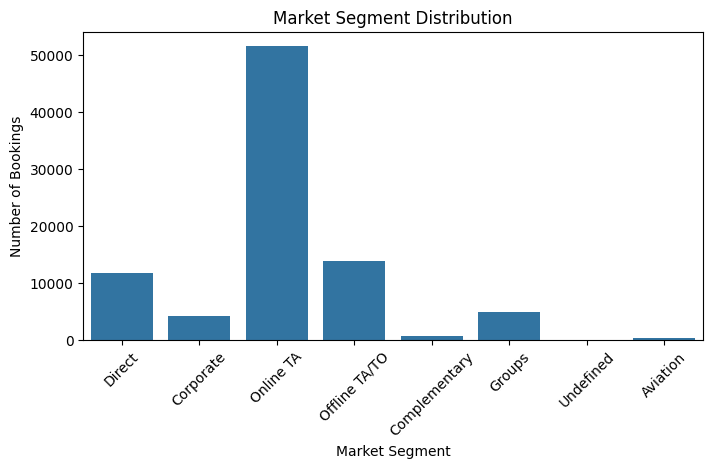

In [ ]:
#Market Segment
plt.figure(figsize=(8,4))

sns.countplot(
    data=df,
    x='market_segment'
)

plt.title("Market Segment Distribution")
plt.xlabel("Market Segment")
plt.ylabel("Number of Bookings")
plt.xticks(rotation=45)
plt.show()

**Insight:** Online TA is the largest market segment. This shows that online travel agencies are an important source of hotel bookings.


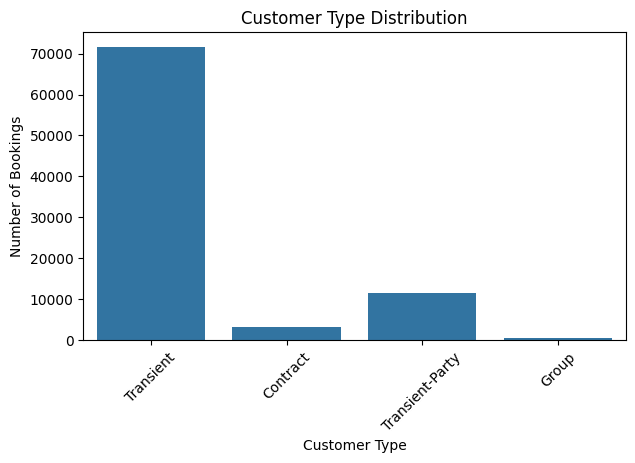

In [ ]:
#Customer Type
plt.figure(figsize=(7,4))

sns.countplot(
    data=df,
    x='customer_type'
)

plt.title("Customer Type Distribution")
plt.xlabel("Customer Type")
plt.ylabel("Number of Bookings")
plt.xticks(rotation=45)
plt.show()

**Insight:** Transient customers make up most bookings. Other customer types have much smaller booking volumes in comparison.


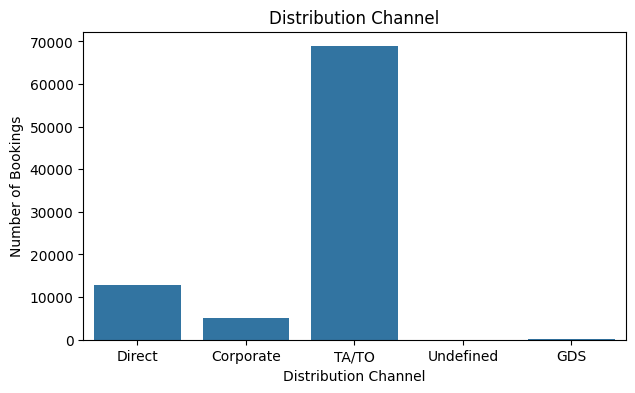

In [ ]:
#Distribution Channel
plt.figure(figsize=(7,4))

sns.countplot(
    data=df,
    x='distribution_channel'
)

plt.title("Distribution Channel")
plt.xlabel("Distribution Channel")
plt.ylabel("Number of Bookings")
plt.show()

**Insight:** TA/TO is the main distribution channel. This indicates that travel agencies and tour operators contribute a large share of bookings.


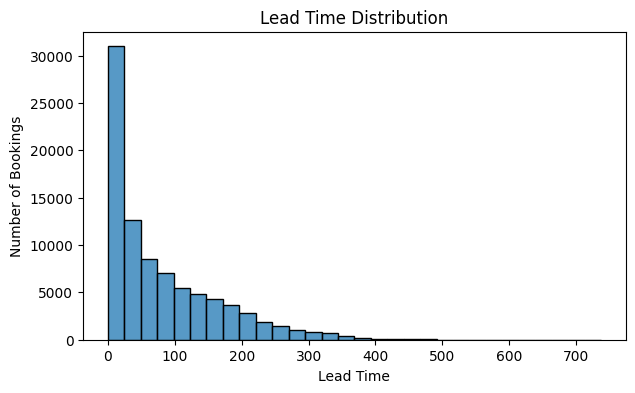

In [ ]:
#Lead Time
plt.figure(figsize=(7,4))

sns.histplot(
    data=df,
    x='lead_time',
    bins=30
)

plt.title("Lead Time Distribution")
plt.xlabel("Lead Time")
plt.ylabel("Number of Bookings")
plt.show()

**Insight:** Lead time is right-skewed, meaning most bookings are made within a shorter period before arrival, while some are made much earlier. This can be an important factor in cancellation prediction.


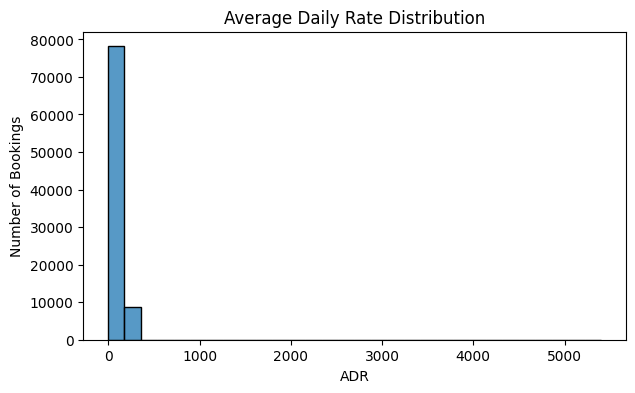

In [ ]:
#ADR
plt.figure(figsize=(7,4))

sns.histplot(
    data=df,
    x='adr',
    bins=30
)

plt.title("Average Daily Rate Distribution")
plt.xlabel("ADR")
plt.ylabel("Number of Bookings")
plt.show()

**Insight:** ADR is right-skewed and contains some extreme values. Most bookings have lower ADR values, while a small number have much higher rates.


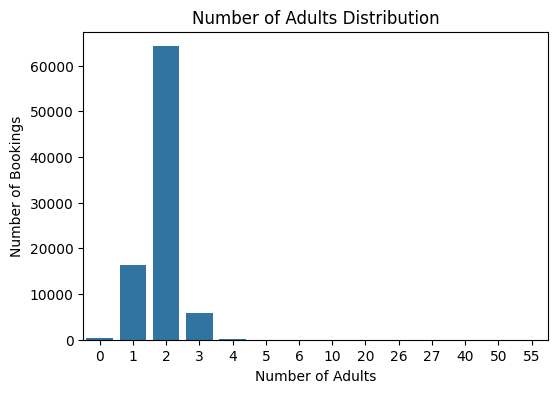

In [ ]:
#Adults
plt.figure(figsize=(6,4))

sns.countplot(
    data=df,
    x='adults'
)

plt.title("Number of Adults Distribution")
plt.xlabel("Number of Adults")
plt.ylabel("Number of Bookings")
plt.show()

**Insight:** Most bookings have 2 adults. Bookings with 1 or more than 2 adults are less common, showing that small groups are common in the dataset.


# **Bivariate Analysis**

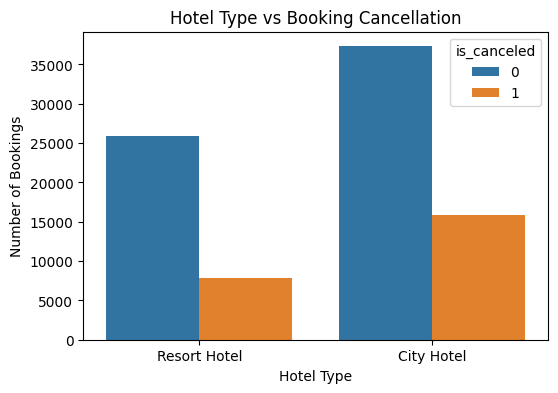

In [ ]:
#Hotel Type vs Cancellation
plt.figure(figsize=(6,4))

sns.countplot(
    data=df,
    x='hotel',
    hue='is_canceled'
)

plt.title("Hotel Type vs Booking Cancellation")
plt.xlabel("Hotel Type")
plt.ylabel("Number of Bookings")
plt.show()

**Insight:** Both hotel types have cancellations, but City Hotel has more cancellations in absolute numbers because it also has more bookings. Hotel type can therefore provide useful information for cancellation prediction.


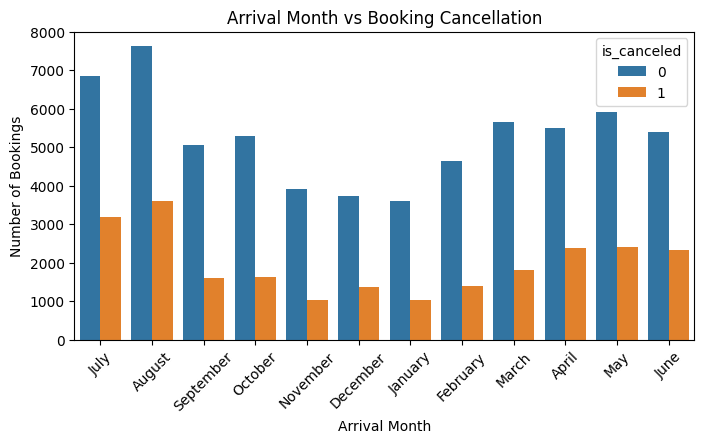

In [ ]:
#Arrival Month vs Cancellation
plt.figure(figsize=(8,4))

sns.countplot(
    data=df,
    x='arrival_date_month',
    hue='is_canceled'
)

plt.title("Arrival Month vs Booking Cancellation")
plt.xlabel("Arrival Month")
plt.ylabel("Number of Bookings")
plt.xticks(rotation=45)
plt.show()

**Insight:** Cancellations vary across arrival months. This suggests that seasonality may have a relationship with booking cancellation behavior.


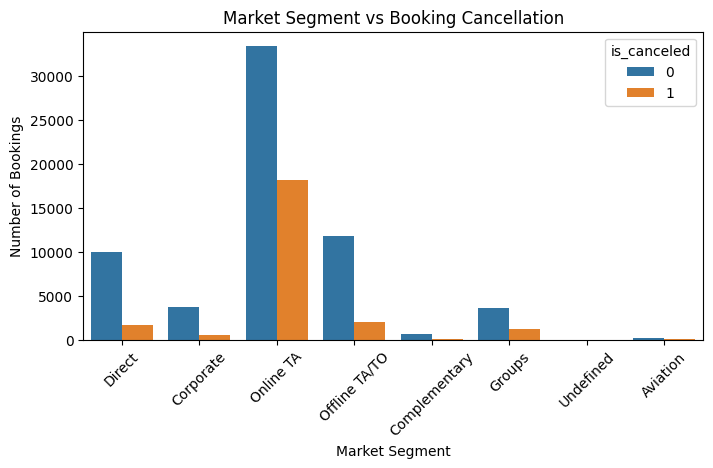

In [ ]:
#Market Segment vs Cancellation
plt.figure(figsize=(8,4))

sns.countplot(
    data=df,
    x='market_segment',
    hue='is_canceled'
)

plt.title("Market Segment vs Booking Cancellation")
plt.xlabel("Market Segment")
plt.ylabel("Number of Bookings")
plt.xticks(rotation=45)
plt.show()

**Insight:** Cancellation counts differ across market segments, with Online TA showing a large number of cancellations. The booking source is therefore useful to consider when predicting cancellations.


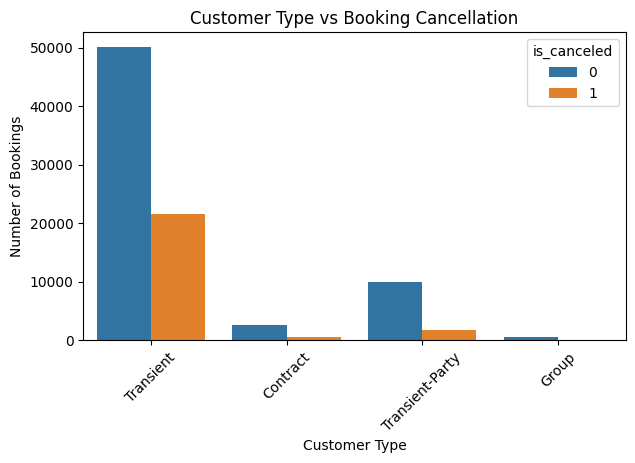

In [ ]:
#Customer Type vs Cancellation
plt.figure(figsize=(7,4))

sns.countplot(
    data=df,
    x='customer_type',
    hue='is_canceled'
)

plt.title("Customer Type vs Booking Cancellation")
plt.xlabel("Customer Type")
plt.ylabel("Number of Bookings")
plt.xticks(rotation=45)
plt.show()

**Insight:** Transient customers have the highest number of cancellations because they also make up most bookings. Customer type can help identify different cancellation patterns.


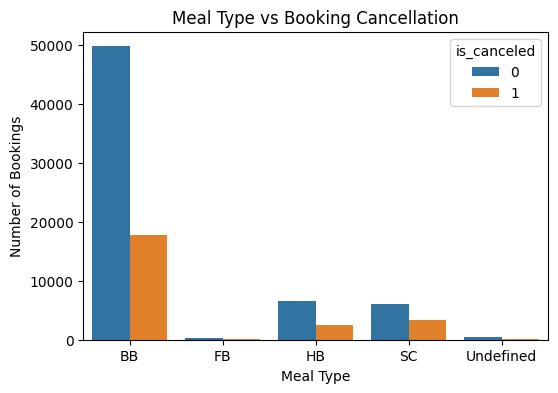

In [ ]:
#Meal Type vs Cancellation
plt.figure(figsize=(6,4))

sns.countplot(
    data=df,
    x='meal',
    hue='is_canceled'
)

plt.title("Meal Type vs Booking Cancellation")
plt.xlabel("Meal Type")
plt.ylabel("Number of Bookings")
plt.show()

**Insight:** BB has the highest number of both canceled and non-canceled bookings because it is the most common meal type. Meal type may provide additional information about booking behavior.


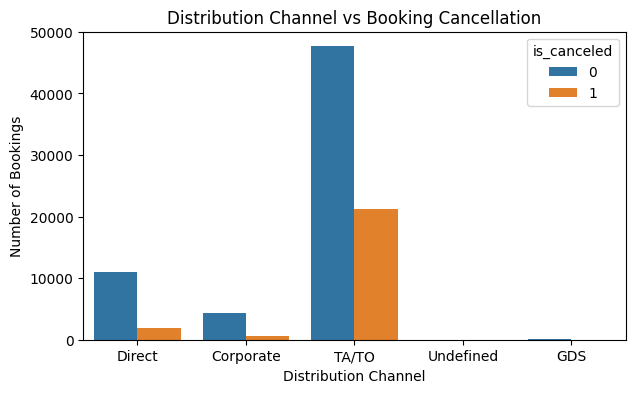

In [ ]:
#Distribution Channel vs Cancellation
plt.figure(figsize=(7,4))

sns.countplot(
    data=df,
    x='distribution_channel',
    hue='is_canceled'
)

plt.title("Distribution Channel vs Booking Cancellation")
plt.xlabel("Distribution Channel")
plt.ylabel("Number of Bookings")
plt.show()

**Insight:** TA/TO has the highest number of both canceled and non-canceled bookings because it is the dominant channel. Distribution channel may therefore be useful for predicting cancellations.


**Overall Insight:**

From my EDA, I found that cancellation behavior varies based on factors like lead time, previous cancellations, deposit type, and booking channel. These patterns help identify bookings that may have a higher chance of cancellation and can help hotels improve revenue and resource planning.